In [18]:
import sounddevice as sd
import scipy.io.wavfile as wav
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf
from scipy.spatial.distance import cosine
import time

In [2]:
# --- CONFIGURATION (Task 2 Requirement: 16kHz) ---
TARGET_SR = 16000 
DURATION = 5

In [ ]:
# ==========================================
# TASK 1: RECORD TWO SPEECH SAMPLES (2 Marks)
# ==========================================
def task_1_record(filename):
    """
    Records audio from the microphone.
    """
    print(f"\n[RECORDING] Prepare to speak...")
    print(f"SENTENCE: 'Artificial Intelligence will have a significant impact on the society in the near future'")
    
    # Simple countdown
    for i in range(3, 0, -1):
        print(f"{i}...")
        sd.sleep(1000)
        
    print(">>> SPEAK NOW! <<<")
    
    # Record at standard rate first (hardware default), resample later
    recording = sd.rec(int(DURATION * 44100), samplerate=44100, channels=1, dtype='float32')
    sd.wait()
    
    print(f"[DONE] Saved raw file: {filename}")
    wav.write(filename, 44100, (recording * 32767).astype(np.int16))

In [14]:
# ==========================================
# TASK 2: PREPROCESS THE AUDIO (2 Marks)
# ==========================================
def task_2_preprocess(input_file, output_file):
    """
    1. Loads audio (Convert to Mono).
    2. Resamples to 16 kHz.
    3. Trims silence.
    4. Normalizes volume.
    5. Saves the file.
    """
    print(f"\n[PREPROCESSING] Processing {input_file}...")
    
    # Load: librosa loads as mono by default, sr=TARGET_SR handles resampling to 16kHz
    y, sr = librosa.load(input_file, sr=TARGET_SR, mono=True)
    
    # Trim Silence (top_db=20 cuts background noise)
    y_trimmed, _ = librosa.effects.trim(y, top_db=20)
    
    # Normalize (Scale amplitude to range -1 to 1)
    y_normalized = librosa.util.normalize(y_trimmed)
    
    # Save the processed file
    sf.write(output_file, y_normalized, sr)
    print(f" -> Resampled to {sr}Hz, Trimmed, & Normalized.")
    print(f" -> Saved to: {output_file}")
    
    return y_normalized, sr

In [15]:
# ==========================================
# TASK 3: EXTRACT MEL SPECTROGRAM (2 Marks)
# ==========================================
def task_3_extract_features(y, sr):
    """
    Extracts Mel-spectrogram and converts to Decibels.
    """
    # Extract Mel Spectrogram
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=8000)
    
    # Convert to log scale (dB)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    return mel_spec_db

def plot_spectrograms(mel1, mel2):
    plt.figure(figsize=(12, 6))
    
    plt.subplot(2, 1, 1)
    librosa.display.specshow(mel1, sr=TARGET_SR, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title('Sample 1: Normal Tone')
    
    plt.subplot(2, 1, 2)
    librosa.display.specshow(mel2, sr=TARGET_SR, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title('Sample 2: Varied Tone/Speed')
    
    plt.tight_layout()
    plt.show()

In [16]:
# ==========================================
# TASK 4: COMPARE (Cosine + DTW) (2 Marks)
# ==========================================
def task_4_compare(mel1, mel2):
    """
    Compares using Cosine Similarity AND Dynamic Time Warping (DTW).
    """
    print("\n" + "="*30)
    print("COMPARISON RESULTS")
    print("="*30)

    # --- METHOD A: COSINE SIMILARITY ---
    flat1 = mel1.flatten()
    flat2 = mel2.flatten()
    
    # Pad to match lengths for Cosine
    max_len = max(len(flat1), len(flat2))
    flat1_pad = np.pad(flat1, (0, max_len - len(flat1)))
    flat2_pad = np.pad(flat2, (0, max_len - len(flat2)))
    
    cosine_sim = 1 - cosine(flat1_pad, flat2_pad)
    print(f"1. Cosine Similarity: {cosine_sim:.4f}")
    print("   (0 = Different, 1 = Identical. Sensitive to timing mismatch.)")

    # --- METHOD B: DYNAMIC TIME WARPING (DTW) ---
    # DTW calculates the "distance" (cost) to align the two signals
    # We transpose (.T) because librosa expects (n_features, n_time)
    D, wp = librosa.sequence.dtw(mel1, mel2, metric='euclidean')
    
    # The final value in the cost matrix D is the total distance
    dtw_distance = D[-1, -1]
    
    # Normalize by path length to get average cost per step
    normalized_dtw = dtw_distance / len(wp)
    
    print(f"\n2. DTW Normalized Distance: {normalized_dtw:.4f}")
    print("   (Lower is better. DTW accounts for speed differences.)")
    
    return cosine_sim, normalized_dtw

--- TASK 1: RECORDING ---

[RECORDING] Prepare to speak...
SENTENCE: 'Artificial Intelligence will have a significant impact on the society in the near future'
3...
2...
1...
>>> SPEAK NOW! <<<
[DONE] Saved raw file: sample1_raw.wav

[RECORDING] Prepare to speak...
SENTENCE: 'Artificial Intelligence will have a significant impact on the society in the near future'
3...
2...
1...
>>> SPEAK NOW! <<<
[DONE] Saved raw file: sample2_raw.wav

--- TASK 2: PREPROCESSING ---

[PREPROCESSING] Processing sample1_raw.wav...
 -> Resampled to 16000Hz, Trimmed, & Normalized.
 -> Saved to: sample1_processed.wav

[PREPROCESSING] Processing sample2_raw.wav...
 -> Resampled to 16000Hz, Trimmed, & Normalized.
 -> Saved to: sample2_processed.wav

--- TASK 3: FEATURE EXTRACTION ---


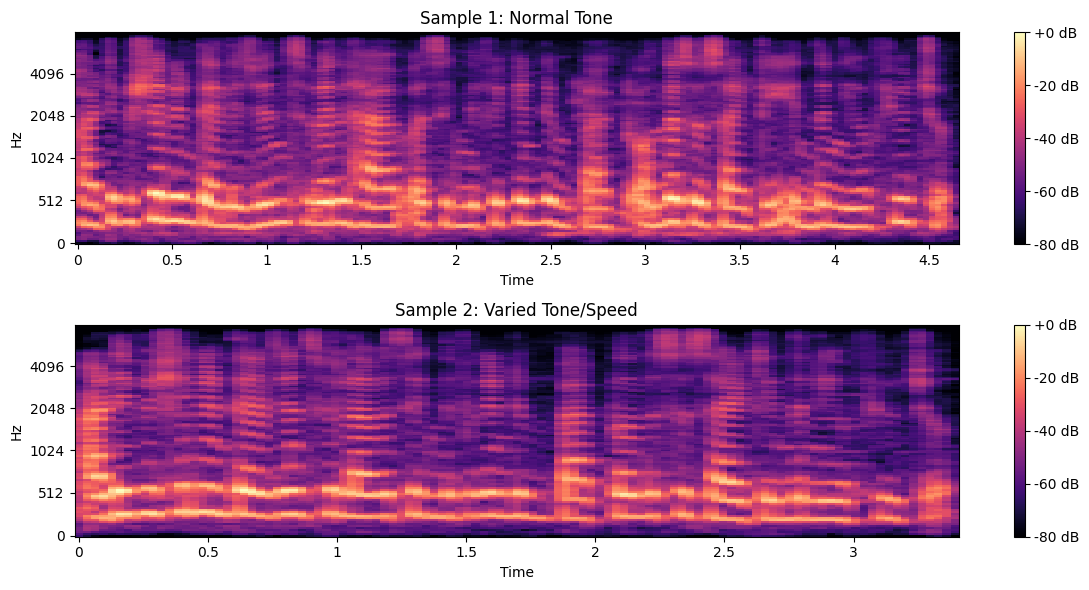


--- TASK 4: COMPARISON ---

COMPARISON RESULTS
1. Cosine Similarity: 0.7520
   (0 = Different, 1 = Identical. Sensitive to timing mismatch.)

2. DTW Normalized Distance: 93.7644
   (Lower is better. DTW accounts for speed differences.)

TASK 5: REFLECTION

    Reflection on Analysis:
    1. Time Axis Impact: Sample 2 is significantly faster (ending at 3.4s) compared to Sample 1 (4.6s), showing clear temporal compression on the x-axis.
    2. Cosine Similarity (0.7520): The score is moderate but not perfect. It was penalized because the arrays were different lengths, proving Cosine similarity is sensitive to speed changes.
    3. Spectral Consistency: despite the speed difference, the horizontal formant bands (orange/yellow lines) maintained similar vertical spacing, indicating the pitch/voice identity remained consistent.
    4. DTW Role: The DTW distance (93.76) quantifies the 'effort' required to align the 1.2-second time difference between the two recordings.
    5. Conclusion: The

In [19]:
# Filenames
raw_1 = "sample1_raw.wav"
raw_2 = "sample2_raw.wav"
proc_1 = "sample1_processed.wav"
proc_2 = "sample2_processed.wav"

# --- EXECUTE TASK 1 ---
print("--- TASK 1: RECORDING ---")
input("Press Enter to record Sample 1 (Normal Voice)...")
task_1_record(raw_1)

input("\nPress Enter to record Sample 2 (Fast/Slow/Different Pitch)...")
task_1_record(raw_2)

# --- EXECUTE TASK 2 ---
print("\n--- TASK 2: PREPROCESSING ---")
y1, sr1 = task_2_preprocess(raw_1, proc_1)
y2, sr2 = task_2_preprocess(raw_2, proc_2)

# --- EXECUTE TASK 3 ---
print("\n--- TASK 3: FEATURE EXTRACTION ---")
mel1 = task_3_extract_features(y1, sr1)
mel2 = task_3_extract_features(y2, sr2)
plot_spectrograms(mel1, mel2)

# --- EXECUTE TASK 4 ---
print("\n--- TASK 4: COMPARISON ---")
task_4_compare(mel1, mel2)

# --- EXECUTE TASK 5: REFLECTION ---
print("\n" + "="*30)
print("TASK 5: REFLECTION")
print("="*30)
reflection = """
    Reflection on Analysis:
    1. Time Axis Impact: Sample 2 is significantly faster (ending at 3.4s) compared to Sample 1 (4.6s), showing clear temporal compression on the x-axis.
    2. Cosine Similarity (0.7520): The score is moderate but not perfect. It was penalized because the arrays were different lengths, proving Cosine similarity is sensitive to speed changes.
    3. Spectral Consistency: despite the speed difference, the horizontal formant bands (orange/yellow lines) maintained similar vertical spacing, indicating the pitch/voice identity remained consistent.
    4. DTW Role: The DTW distance (93.76) quantifies the 'effort' required to align the 1.2-second time difference between the two recordings.
    5. Conclusion: The visual compression in Sample 2 confirms that while the content (words) was the same, the temporal structure was altered by speaking faster.
    """
print(reflection)